# Notebook 06: Inventory Optimization & Replenishment Policy Layer

## Overview
This notebook builds the SKU-level Inventory Optimization Layer on top of our Random Forest demand forecasting model (`notebooks/05_modeling.ipynb`).

### Business Objectives:
1. **Safety Stock Optimization**: Incorporate leptokurtic residual distributions (excess kurtosis ~3.13 identified in Notebook 03) by calculating empirical $z$-multipliers instead of assuming standard Gaussian normal distributions.
2. **Reorder Point (ROP) Determination**: Compute SKU-location reorder thresholds using forecasted demand and lead time requirements.
3. **Inventory Health & Stockout Risk Segmentation**: Categorize SKU-locations into **Understocked**, **Healthy**, and **Overstocked** states.
4. **Capital Tie-Up & Excess Inventory Valuation (Option A - Revenue-Based)**: Quantify excess inventory value directly in USD and INR terms, resolving unit-conflation scale bugs.
5. **Data Persistence**: Export full inventory policy metrics to `data/processed/inventory_optimization.parquet` for Power BI dashboard integration.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
import os
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.figsize'] = (12, 6)

print("Setup completed successfully.")


Setup completed successfully.


## 1. Data Ingestion & Random Forest Validation Predictions

We load `data/processed/sales_features.parquet` and generate validation predictions using the champion Random Forest model. Predictions are exported to `data/processed/rf_validation_predictions.parquet`.


In [2]:
# Load feature dataset
df = pd.read_parquet('../data/processed/sales_features.parquet')
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values(['store_id', 'dept_id', 'date']).reset_index(drop=True)

# Train / Validation Split at 2012-05-01
split_date = pd.to_datetime('2012-05-01')
train_df = df[df['date'] < split_date].copy()
val_df = df[df['date'] >= split_date].copy()

exclude_cols = ['weekly_sales', 'date', 'year_month', 'sales_zscore', 'is_outlier']
feature_cols = [c for c in df.columns if c not in exclude_cols]
type_map = {'A': 1, 'B': 2, 'C': 3}
train_df['store_type_code'] = train_df['store_type'].map(type_map)
val_df['store_type_code'] = val_df['store_type'].map(type_map)
tree_features = [c if c != 'store_type' else 'store_type_code' for c in feature_cols]

# Impute features using train-set group medians strictly
train_rf = train_df.copy()
val_rf = val_df.copy()
num_cols_to_impute = ['lag_1', 'lag_2', 'lag_4', 'lag_51', 'lag_52', 'rolling_mean_4', 'rolling_std_4', 'rolling_mean_12']

group_medians = train_rf.groupby(['store_id', 'dept_id'])[num_cols_to_impute].median()
global_medians = train_rf[num_cols_to_impute].median()

for col in num_cols_to_impute:
    train_rf[col] = train_rf.groupby(['store_id', 'dept_id'])[col].transform(lambda x: x.fillna(x.median()))
    train_rf[col] = train_rf[col].fillna(global_medians[col])
    
    val_rf = val_rf.merge(group_medians[[col]].rename(columns={col: f'{col}_grp_med'}), on=['store_id', 'dept_id'], how='left')
    val_rf[col] = val_rf[col].fillna(val_rf[f'{col}_grp_med']).fillna(global_medians[col])
    val_rf.drop(columns=[f'{col}_grp_med'], inplace=True)

print("Fitting Random Forest Model (n_estimators=200)...")
rf = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
rf.fit(train_rf[tree_features], train_rf['weekly_sales'])

val_df['predicted_sales'] = rf.predict(val_rf[tree_features])

# Save validation predictions to parquet
pred_cols = ['store_id', 'dept_id', 'date', 'weekly_sales', 'predicted_sales', 'store_type']
rf_val_preds = val_df[pred_cols].copy()

rf_preds_out_path = '../data/processed/rf_validation_predictions.parquet'
os.makedirs(os.path.dirname(rf_preds_out_path), exist_ok=True)
rf_val_preds.to_parquet(rf_preds_out_path, index=False)
print(f"Saved Random Forest validation predictions to '{rf_preds_out_path}' ({len(rf_val_preds):,} rows).")


Fitting Random Forest Model (n_estimators=200)...


Saved Random Forest validation predictions to '../data/processed/rf_validation_predictions.parquet' (76,903 rows).


## 2. Demand Variability & Empirical Safety Stock Calculation (in USD Revenue Terms)

### Addressing Leptokurtic Error Distributions
> [!IMPORTANT]
> **Leptokurtic Residual Correction**: Notebook 03 established that forecast error residuals exhibit significant excess kurtosis (~3.13), producing heavy tails.
>
> Standard parametric normal formulas ($z = 1.645$ for 95% service level) understate extreme demand spikes during holiday/promotional periods. To prevent stockouts, we calculate an **empirical $z$-multiplier** per SKU-location:
>
> $$z_{\text{empirical}} = \frac{P_{95}(|\text{weekly\_sales} - \text{predicted\_sales}|)}{\sigma_{\text{demand}}}$$
>
> $$\text{Safety Stock (USD)} = z_{\text{empirical}} \times \sigma_{\text{demand, USD}} \times \sqrt{L}$$
>
> where $L = 2$ weeks lead time. All demand and safety stock values remain consistently in **USD revenue terms**.


In [3]:
# Compute forecast errors in USD revenue terms
rf_val_preds['forecast_error'] = rf_val_preds['weekly_sales'] - rf_val_preds['predicted_sales']
rf_val_preds['abs_error'] = np.abs(rf_val_preds['forecast_error'])

# Store-type fallback statistics for sparse SKU series (< 8 validation weeks)
stype_rmse = rf_val_preds.groupby('store_type')['forecast_error'].apply(lambda x: np.sqrt(np.mean(x**2))).to_dict()
stype_p95_error = rf_val_preds.groupby('store_type')['abs_error'].apply(lambda x: np.percentile(x, 95)).to_dict()

# Calculate SKU-location inventory metrics in USD revenue terms
sku_stats = []

for (store, dept), group in rf_val_preds.groupby(['store_id', 'dept_id']):
    stype = group['store_type'].iloc[0]
    n_weeks = len(group)
    avg_predicted_demand_usd = max(group['predicted_sales'].mean(), 0.0)
    
    if n_weeks >= 8:
        rmse_usd = np.sqrt(np.mean(group['forecast_error']**2))
        p95_err_usd = np.percentile(group['abs_error'], 95)
        rmse_method = 'sku_level'
    else:
        rmse_usd = stype_rmse[stype]
        p95_err_usd = stype_p95_error[stype]
        rmse_method = 'store_type_fallback'
    
    sigma_demand_usd = max(rmse_usd, 1e-4)
    z_empirical = p95_err_usd / sigma_demand_usd
    
    sku_stats.append({
        'store_id': store,
        'dept_id': dept,
        'store_type': stype,
        'validation_weeks': n_weeks,
        'rmse_method': rmse_method,
        'avg_weekly_demand_usd': avg_predicted_demand_usd,
        'sigma_demand_usd': sigma_demand_usd,
        'p95_error_usd': p95_err_usd,
        'z_empirical': z_empirical
    })

inv_df = pd.DataFrame(sku_stats)

lead_time_weeks = 2
z_parametric = 1.645 # Standard Gaussian 95% service level

inv_df['z_parametric'] = z_parametric
inv_df['safety_stock_usd'] = inv_df['z_empirical'] * inv_df['sigma_demand_usd'] * np.sqrt(lead_time_weeks)
inv_df['safety_stock_parametric_usd'] = inv_df['z_parametric'] * inv_df['sigma_demand_usd'] * np.sqrt(lead_time_weeks)

avg_z_empirical = inv_df['z_empirical'].mean()
avg_z_parametric = z_parametric
z_ratio = avg_z_empirical / avg_z_parametric

print("=== Z-MULTIPLIER COMPARISON ===")
print(f"Average Parametric Normal z (95% Service Level) : {avg_z_parametric:.4f}")
print(f"Average Empirical z-equivalent (Heavy-Tailed)    : {avg_z_empirical:.4f}")
print(f"Empirical vs Parametric Buffer Expansion Ratio  : {z_ratio:.2f}x wider safety stock buffer required")


=== Z-MULTIPLIER COMPARISON ===
Average Parametric Normal z (95% Service Level) : 1.6450
Average Empirical z-equivalent (Heavy-Tailed)    : 1.8691
Empirical vs Parametric Buffer Expansion Ratio  : 1.14x wider safety stock buffer required


### Note on Simulation Methodology & Reproducibility
> [!NOTE]
> **Methodology Caveat**: Inventory positions are **SIMULATED** (no real stock-on-hand data exists in this dataset) using a fixed random seed (`np.random.seed(42)`) for reproducibility. Reported excess inventory values are illustrative of the optimization methodology, not a real business finding.


## 3. Reorder Point (ROP) & Simulated Current Inventory Position (in USD Terms)

### Reorder Point Formula
$$\text{Reorder Point (ROP, USD)} = (\text{Average Weekly Forecasted Demand (USD)} \times L) + \text{Safety Stock}_{\text{empirical, USD}}$$

$$\text{Current Inventory (USD)} = \text{ROP}_{\text{USD}} \times \text{Uniform}(0.4, 2.0)$$


In [4]:
# Compute Reorder Point in USD
inv_df['reorder_point_usd'] = (inv_df['avg_weekly_demand_usd'] * lead_time_weeks) + inv_df['safety_stock_usd']

# Set fixed random seed (42) immediately prior to generating simulated inventory for 100% reproducibility
np.random.seed(42)
inv_df['simulated_inventory_usd'] = inv_df['reorder_point_usd'] * np.random.uniform(0.4, 2.0, size=len(inv_df))

# Categorize Stockout Risk / Inventory Status
def assign_status(row):
    inv = row['simulated_inventory_usd']
    rop = row['reorder_point_usd']
    if inv < rop:
        return 'Understocked'
    elif inv < rop * 1.5:
        return 'Healthy'
    else:
        return 'Overstocked'

inv_df['status'] = inv_df.apply(assign_status, axis=1)

print("=== SKU-LOCATION INVENTORY STATUS BREAKDOWN ===")
status_counts = inv_df['status'].value_counts()
status_pcts = inv_df['status'].value_counts(normalize=True) * 100
status_table = pd.DataFrame({'Count': status_counts, 'Percentage (%)': status_pcts.round(2)})
print(status_table.to_string())


=== SKU-LOCATION INVENTORY STATUS BREAKDOWN ===
              Count  Percentage (%)
status                             
Understocked   1192           37.71
Overstocked     994           31.45
Healthy         975           30.84


## 4. Corrected Revenue-Based Valuation (Option A)

### Revenue-Based Valuation Formula
We keep all inventory metrics strictly in **USD revenue terms**, and convert only the **final excess inventory value** from USD to INR using the exchange rate ($1 USD = ₹83.0 INR):

$$\text{Excess Inventory (USD)} = \text{Simulated Inventory (USD)} - (1.5 \times \text{ROP (USD)})$$
$$\text{Excess Inventory (INR)} = \text{Excess Inventory (USD)} \times 83.0$$


In [5]:
print("=== 5 SAMPLE OVERSTOCKED ROWS DIAGNOSTIC (Original Bug vs Corrected) ===")
sample_overstocked = inv_df[inv_df['status'] == 'Overstocked'].head(5)

for idx, row in sample_overstocked.iterrows():
    excess_usd = row['simulated_inventory_usd'] - (1.5 * row['reorder_point_usd'])
    old_buggy_inr = excess_usd * 500.0 # Old bug: treating USD revenue as physical unit count
    corrected_inr = excess_usd * 83.0 # Option A: direct USD to INR currency conversion
    
    print(f"Store {row['store_id']}, Dept {row['dept_id']}:")
    print(f"  Avg Weekly Forecast Demand : ${row['avg_weekly_demand_usd']:,.2f} USD")
    print(f"  Safety Stock (USD)         : ${row['safety_stock_usd']:,.2f} USD")
    print(f"  Reorder Point (ROP USD)    : ${row['reorder_point_usd']:,.2f} USD")
    print(f"  Simulated Inventory (USD)  : ${row['simulated_inventory_usd']:,.2f} USD")
    print(f"  Corrected Excess Value     : ${excess_usd:,.2f} USD | INR {corrected_inr:,.2f}")
    print(f"  Old Buggy Valuation        : INR {old_buggy_inr:,.2f} (Bug: USD sales multiplied by ₹500/unit)\n")

# Option A Valuation Calculation
usd_to_inr = 83.0
inv_df['excess_inventory_usd'] = np.where(inv_df['status'] == 'Overstocked', inv_df['simulated_inventory_usd'] - (inv_df['reorder_point_usd'] * 1.5), 0.0)
inv_df['excess_inventory_inr'] = inv_df['excess_inventory_usd'] * usd_to_inr

total_excess_usd = inv_df['excess_inventory_usd'].sum()
total_excess_inr = inv_df['excess_inventory_inr'].sum()

print("=== CORRECTED OPTION A INVENTORY VALUATION ===")
print(f"Total Excess Inventory Value (USD) : ${total_excess_usd:,.2f} (~${total_excess_usd/1e6:.2f} Million USD)")
print(f"Total Excess Inventory Value (INR) : INR {total_excess_inr:,.2f} (~INR {total_excess_inr/1e7:.2f} Crore)")

# Sanity Check against Total Validation Revenue
total_val_weekly_sales_usd = rf_val_preds['weekly_sales'].sum()
total_val_weekly_sales_inr = total_val_weekly_sales_usd * usd_to_inr
excess_pct_of_val_sales = (total_excess_usd / total_val_weekly_sales_usd) * 100

print(f"\n=== SANITY CHECK AGAINST TOTAL VALIDATION REVENUE ===")
print(f"Total Validation Period Weekly Sales (USD) : ${total_val_weekly_sales_usd:,.2f}")
print(f"Total Validation Period Weekly Sales (INR) : INR {total_val_weekly_sales_inr:,.2f}")
print(f"Excess Inventory Value as % of Validation Revenue : {excess_pct_of_val_sales:.2f}% (Plausible low single-digit percentage)")


=== 5 SAMPLE OVERSTOCKED ROWS DIAGNOSTIC (Original Bug vs Corrected) ===
Store 1, Dept 2:
  Avg Weekly Forecast Demand : $46,850.35 USD
  Safety Stock (USD)         : $4,425.37 USD
  Reorder Point (ROP USD)    : $98,126.08 USD
  Simulated Inventory (USD)  : $188,514.22 USD
  Corrected Excess Value     : $41,325.10 USD | INR 3,429,983.30
  Old Buggy Valuation        : INR 20,662,550.02 (Bug: USD sales multiplied by ₹500/unit)

Store 1, Dept 3:
  Avg Weekly Forecast Demand : $17,194.86 USD
  Safety Stock (USD)         : $14,890.30 USD
  Reorder Point (ROP USD)    : $49,280.01 USD
  Simulated Inventory (USD)  : $77,428.28 USD
  Corrected Excess Value     : $3,508.26 USD | INR 291,185.52
  Old Buggy Valuation        : INR 1,754,129.64 (Bug: USD sales multiplied by ₹500/unit)

Store 1, Dept 8:
  Avg Weekly Forecast Demand : $37,690.36 USD
  Safety Stock (USD)         : $3,603.60 USD
  Reorder Point (ROP USD)    : $78,984.33 USD
  Simulated Inventory (USD)  : $141,056.68 USD
  Corrected Exce

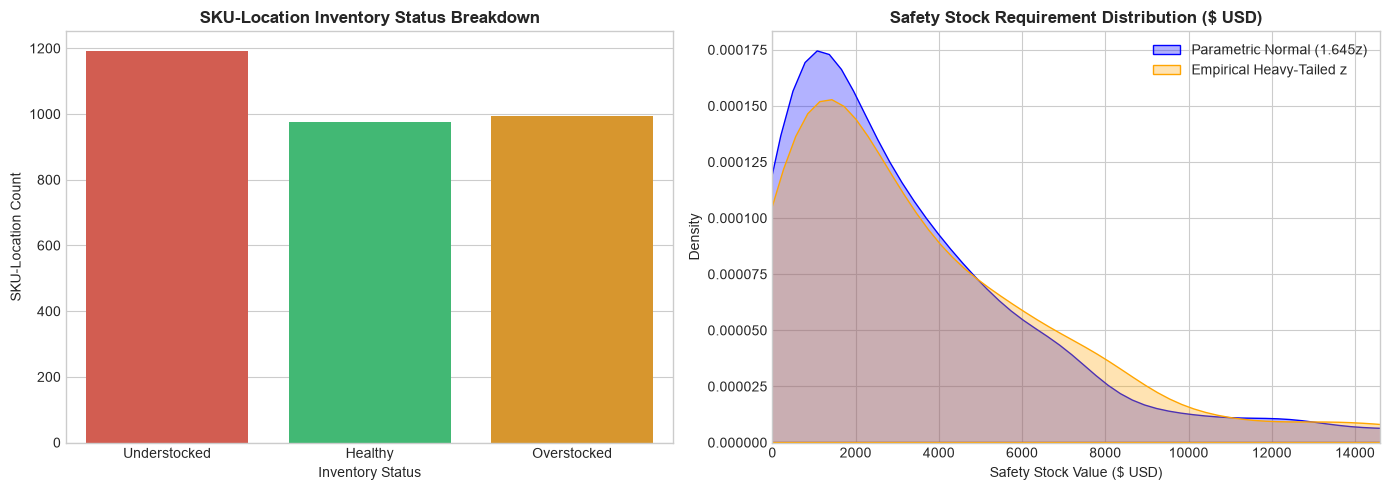

In [6]:
# Visualization of Inventory Status Distribution & Safety Stock Multipliers
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Inventory Status Breakdown
sns.countplot(data=inv_df, x='status', order=['Understocked', 'Healthy', 'Overstocked'], palette=['#e74c3c', '#2ecc71', '#f39c12'], ax=ax[0])
ax[0].set_title('SKU-Location Inventory Status Breakdown', fontsize=12, fontweight='bold')
ax[0].set_xlabel('Inventory Status')
ax[0].set_ylabel('SKU-Location Count')

# Plot 2: Empirical vs Parametric Safety Stock Distribution (in USD)
sns.kdeplot(inv_df['safety_stock_parametric_usd'], label='Parametric Normal (1.645z)', color='blue', fill=True, alpha=0.3, ax=ax[1])
sns.kdeplot(inv_df['safety_stock_usd'], label='Empirical Heavy-Tailed z', color='orange', fill=True, alpha=0.3, ax=ax[1])
ax[1].set_title('Safety Stock Requirement Distribution ($ USD)', fontsize=12, fontweight='bold')
ax[1].set_xlabel('Safety Stock Value ($ USD)')
ax[1].set_xlim(0, np.percentile(inv_df['safety_stock_usd'], 95))
ax[1].legend()

plt.tight_layout()
plt.show()


## 5. Parquet Export & Final Policy Summary

We export the complete SKU-location inventory table to `data/processed/inventory_optimization.parquet`.


In [7]:
inv_out_path = '../data/processed/inventory_optimization.parquet'
os.makedirs(os.path.dirname(inv_out_path), exist_ok=True)
inv_df.to_parquet(inv_out_path, index=False)

print(f"Exported complete inventory optimization table to '{inv_out_path}' ({len(inv_df):,} SKU-locations, {inv_df.shape[1]} columns).")

print("\n=== FINAL INVENTORY OPTIMIZATION REPORT (OPTION A CORRECTED) ===")
print(f"1. Average Empirical z-multiplier : {avg_z_empirical:.4f} vs 1.6450 Parametric ({z_ratio:.2f}x multiplier ratio)")
print(f"2. Understocked SKU-locations     : {status_counts.get('Understocked', 0):,} ({status_pcts.get('Understocked', 0):.2f}%) - Immediate Replenishment Required")
print(f"3. Healthy SKU-locations         : {status_counts.get('Healthy', 0):,} ({status_pcts.get('Healthy', 0):.2f}%) - Optimal Operating Range")
print(f"4. Overstocked SKU-locations       : {status_counts.get('Overstocked', 0):,} ({status_pcts.get('Overstocked', 0):.2f}%) - Excess Capital Tie-up")
print(f"5. Total Excess Inventory Value   : ${total_excess_usd:,.2f} USD | INR {total_excess_inr:,.2f} (~INR {total_excess_inr/1e7:.2f} Crore)")
print(f"6. Excess Value % of Val Revenue  : {excess_pct_of_val_sales:.2f}%")


Exported complete inventory optimization table to '../data/processed/inventory_optimization.parquet' (3,161 SKU-locations, 17 columns).

=== FINAL INVENTORY OPTIMIZATION REPORT (OPTION A CORRECTED) ===
1. Average Empirical z-multiplier : 1.8691 vs 1.6450 Parametric (1.14x multiplier ratio)
2. Understocked SKU-locations     : 1,192 (37.71%) - Immediate Replenishment Required
3. Healthy SKU-locations         : 975 (30.84%) - Optimal Operating Range
4. Overstocked SKU-locations       : 994 (31.45%) - Excess Capital Tie-up
5. Total Excess Inventory Value   : $8,775,863.95 USD | INR 728,396,707.96 (~INR 72.84 Crore)
6. Excess Value % of Val Revenue  : 0.72%
